In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [113]:
df = pd.read_csv("/kaggle/input/mot-time-duration/mot_recording_time_and_duration.csv")

In [114]:
df


,Duration,Time,Week Day
0,0:42:24,2023-09-26 22:08 GMT+3:30,Tuesday
1,0:08:16,2023-09-26 22:02 GMT+3:30,Tuesday
2,0:23:37,2023-09-26 21:54 GMT+3:30,Tuesday
3,0:09:15,2023-09-26 21:39 GMT+3:30,Tuesday
4,0:14:35,2023-09-26 21:38 GMT+3:30,Tuesday
...,...,...,...
185,0:14:50,2023-10-01 23:16 GMT+3:30,Sunday
186,0:23:09,2023-10-01 23:42 GMT+3:30,Sunday
187,0:21:49,2023-10-01 23:19 GMT+3:30,Sunday
188,0:28:18,2023-10-01 23:28 GMT+3:30,Sunday


In [115]:
def time_to_minutes(duration_str):
    hours, minutes, seconds = map(int, duration_str.split(':'))
    total_seconds = hours * 3600 + minutes * 60 + seconds
    total_minutes = total_seconds / 60 
    formatted_minutes = '{:.2f}'.format(total_minutes)
    return formatted_minutes

df['duration_minutes'] = df['Duration'].apply(time_to_minutes)
print(df)

    Duration                       Time Week Day duration_minutes
0    0:42:24  2023-09-26 22:08 GMT+3:30  Tuesday            42.40
1    0:08:16  2023-09-26 22:02 GMT+3:30  Tuesday             8.27
2    0:23:37  2023-09-26 21:54 GMT+3:30  Tuesday            23.62
3    0:09:15  2023-09-26 21:39 GMT+3:30  Tuesday             9.25
4    0:14:35  2023-09-26 21:38 GMT+3:30  Tuesday            14.58
..       ...                        ...      ...              ...
185  0:14:50  2023-10-01 23:16 GMT+3:30   Sunday            14.83
186  0:23:09  2023-10-01 23:42 GMT+3:30   Sunday            23.15
187  0:21:49  2023-10-01 23:19 GMT+3:30   Sunday            21.82
188  0:28:18  2023-10-01 23:28 GMT+3:30   Sunday            28.30
189  0:18:21  2023-10-01 23:46 GMT+3:30   Sunday            18.35

[190 rows x 4 columns]


In [116]:
df['Time'] = pd.to_datetime(df['Time'])

def convert_timezone(dt):
    return dt - pd.DateOffset(hours=6, minutes=30)  # Convert from GMT+3:30 to GMT-3


df['Time'] = df['Time'].apply(convert_timezone)
print(df)

    Duration                      Time Week Day duration_minutes
0    0:42:24 2023-09-26 15:38:00-03:30  Tuesday            42.40
1    0:08:16 2023-09-26 15:32:00-03:30  Tuesday             8.27
2    0:23:37 2023-09-26 15:24:00-03:30  Tuesday            23.62
3    0:09:15 2023-09-26 15:09:00-03:30  Tuesday             9.25
4    0:14:35 2023-09-26 15:08:00-03:30  Tuesday            14.58
..       ...                       ...      ...              ...
185  0:14:50 2023-10-01 16:46:00-03:30   Sunday            14.83
186  0:23:09 2023-10-01 17:12:00-03:30   Sunday            23.15
187  0:21:49 2023-10-01 16:49:00-03:30   Sunday            21.82
188  0:28:18 2023-10-01 16:58:00-03:30   Sunday            28.30
189  0:18:21 2023-10-01 17:16:00-03:30   Sunday            18.35

[190 rows x 4 columns]


/tmp/ipykernel_32/1013555034.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])


In [117]:
df['duration_minutes'] = df['duration_minutes'].astype(float)

In [118]:
df['Time'] = pd.to_datetime(df['Time'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce')
df['Time'] = df['Time'].dt.strftime('%H:%M:%S')

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Duration          190 non-null    object 
 1   Time              190 non-null    object 
 2   Week Day          190 non-null    object 
 3   duration_minutes  190 non-null    float64
dtypes: float64(1), object(3)
memory usage: 6.1+ KB


In [120]:
df = df.drop(columns=['Duration'])

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Time              190 non-null    object 
 1   Week Day          190 non-null    object 
 2   duration_minutes  190 non-null    float64
dtypes: float64(1), object(2)
memory usage: 4.6+ KB


/tmp/ipykernel_32/3096532053.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])
/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/tmp/ipykernel_32/3096532053.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


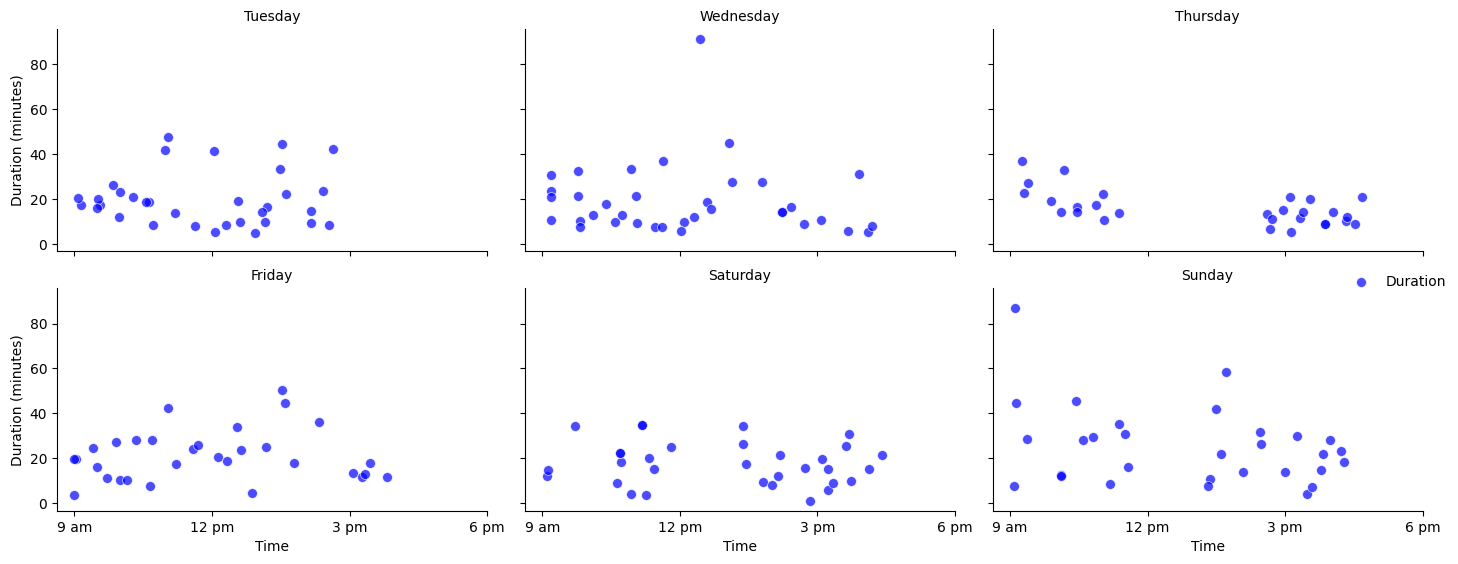

In [122]:
df['Time'] = pd.to_datetime(df['Time'])

g = sns.FacetGrid(df, col='Week Day', col_wrap=3, height=3, aspect=1.5)
g.map(sns.scatterplot, 'Time', 'duration_minutes', marker='o', s=50, color='b', label='Duration', alpha=0.7)

g.set_axis_labels('Time', 'Duration (minutes)')
g.set_titles('{col_name}')

x_ticks = [df['Time'].min() + pd.DateOffset(hours=3 * i) for i in range(4)]
x_labels = ['9 am', '12 pm', '3 pm', '6 pm']
g.set(xticks=x_ticks, xticklabels=x_labels)

g.add_legend()

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.savefig("days_duration.png", dpi=300, bbox_inches='tight')
plt.show()


/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/tmp/ipykernel_32/1081887722.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


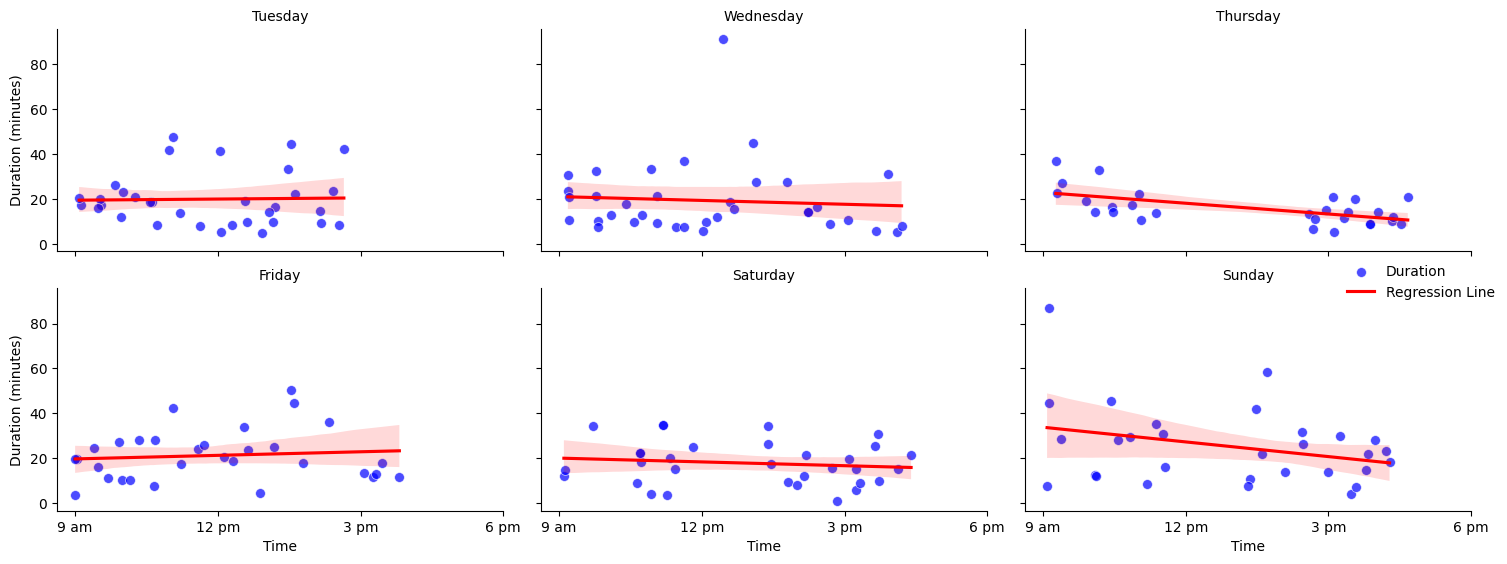

In [123]:
df['Time_numeric'] = (df['Time'] - df['Time'].min()).dt.total_seconds() / 3600

g = sns.FacetGrid(df, col='Week Day', col_wrap=3, height=3, aspect=1.5)
g.map(sns.scatterplot, 'Time_numeric', 'duration_minutes', marker='o', s=50, color='b', label='Duration', alpha=0.7)

g.map(sns.regplot, 'Time_numeric', 'duration_minutes', scatter=False, color='red', label='Regression Line')

g.set_axis_labels('Time', 'Duration (minutes)')
g.set_titles('{col_name}')

x_ticks = [0, 3, 6, 9]
x_labels = ['9 am', '12 pm', '3 pm', '6 pm']
g.set(xticks=x_ticks, xticklabels=x_labels)

g.add_legend()

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.savefig("days_duration_reg.png", dpi=300, bbox_inches='tight')
plt.show()

In [124]:
df

,Time,Week Day,duration_minutes,Time_numeric
0,2023-10-29 15:38:00,Tuesday,42.40,5.650000
1,2023-10-29 15:32:00,Tuesday,8.27,5.550000
2,2023-10-29 15:24:00,Tuesday,23.62,5.416667
3,2023-10-29 15:09:00,Tuesday,9.25,5.166667
4,2023-10-29 15:08:00,Tuesday,14.58,5.150000
...,...,...,...,...
185,2023-10-29 16:46:00,Sunday,14.83,6.783333
186,2023-10-29 17:12:00,Sunday,23.15,7.216667
187,2023-10-29 16:49:00,Sunday,21.82,6.833333
188,2023-10-29 16:58:00,Sunday,28.30,6.983333


In [125]:
df['hour'] = df['Time'].dt.round('H')
df['hour'] = df['hour'].dt.hour

In [126]:
df.head(50)

,Time,Week Day,duration_minutes,Time_numeric,hour
0,2023-10-29 15:38:00,Tuesday,42.40,5.650000,16
1,2023-10-29 15:32:00,Tuesday,8.27,5.550000,16
2,2023-10-29 15:24:00,Tuesday,23.62,5.416667,15
3,2023-10-29 15:09:00,Tuesday,9.25,5.166667,15
4,2023-10-29 15:08:00,Tuesday,14.58,5.150000,15
5,2023-10-29 14:36:00,Tuesday,22.17,4.616667,15
6,2023-10-29 14:31:00,Tuesday,44.55,4.533333,15
7,2023-10-29 14:28:00,Tuesday,33.40,4.483333,14
8,2023-10-29 14:11:00,Tuesday,16.35,4.200000,14
9,2023-10-29 14:09:00,Tuesday,9.72,4.166667,14


In [127]:
day_to_group = {
    'Tuesday': 'school_day',
    'Wednesday': 'working_day',
    'Thursday': 'working_day',
    'Friday': 'working_day',
    'Saturday': 'weekend',
    'Sunday': 'weekend'
}
df['day_group'] = df['Week Day'].map(day_to_group)
grouped_df = df.groupby(['day_group', 'hour'])['duration_minutes'].mean().reset_index()

In [128]:
grouped_df

,day_group,hour,duration_minutes
0,school_day,10,18.342500
1,school_day,11,19.716000
2,school_day,12,24.771667
3,school_day,13,15.705000
4,school_day,14,15.290000
5,school_day,15,22.834000
6,school_day,16,25.335000
7,weekend,10,32.403333
8,weekend,11,26.142500
9,weekend,12,21.099333


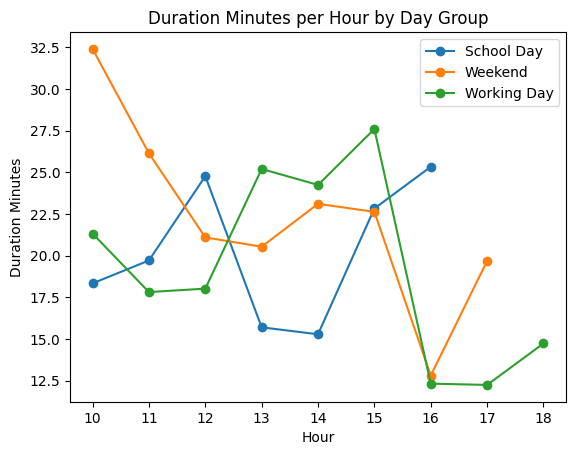

In [129]:
school_day_data = grouped_df[grouped_df['day_group'] == 'school_day']
weekend_data = grouped_df[grouped_df['day_group'] == 'weekend']
working_day_data = grouped_df[grouped_df['day_group'] == 'working_day']

plt.plot(school_day_data['hour'], school_day_data['duration_minutes'], label='School Day', marker='o')
plt.plot(weekend_data['hour'], weekend_data['duration_minutes'], label='Weekend', marker='o')
plt.plot(working_day_data['hour'], working_day_data['duration_minutes'], label='Working Day', marker='o')

plt.title('Duration Minutes per Hour by Day Group')
plt.xlabel('Hour')
plt.ylabel('Duration Minutes')
plt.legend()

plt.savefig("day_group_duration_trends.png", dpi=300, bbox_inches='tight')
plt.show()